In [1]:
from ccka.models.kernel import KernelModel
from ccka.circuits.angleEmbeddingKernel import quackEmbeddingCircuit
from ccka.aligner.kta import fullKTA, centroidBasedKTA, quackKTA, randomKTA, greedyKTA
import pennylane as qml
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import time
import os
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [2]:
def load_data(dataset_path):
    data = jnp.load(dataset_path, allow_pickle=True).item()
    X = jnp.asarray(data['x_train'])
    y = jnp.asarray(data['y_train'])
    x_test = jnp.asarray(data['x_test'])
    y_test = jnp.asarray(data['y_test'])

    X_combined = jnp.concatenate([X, x_test], axis=0)
    y_combined = jnp.concatenate([y, y_test], axis=0)

    return X_combined, y_combined

In [3]:
def run_experiment(method, dataset, dataset_path, centroids, num_iterations):

    print(f"Running {method} on {dataset} with centroids={centroids} and iterations={num_iterations}")
    
    X, y = load_data(dataset_path)

    kernel = quackEmbeddingCircuit(
                                num_qubits = 4,
                                reps = 5,
                                reupload = True
                        )
    init_weights = kernel.init_weights()
    model = KernelModel(circuit = kernel)

    if method == 'fullKTA':
        aligner = fullKTA(
            kernel_model= model,
            data = X,
            labels = y,
            matrix_type='regular',
            split_size=0.5,
            learning_rate=0.1,
            optimizer= 'adam',
            epochs=num_iterations
        )
    
    elif method == 'centroidBasedKTA':
        num_iterations = int(num_iterations / 10)
        aligner = centroidBasedKTA(
                    kernel_model= model,
                    data = X,
                    labels = y,
                    matrix_type='regular',
                    clustering='regular',
                    split_size=0.50,
                    centroids= centroids,
                    lambda_co=0.0,
                    lambda_kao=0.0,
                    epochs=num_iterations,
                    eps=0.001,
                    alpha=0.01
        )
    
    elif method == 'greedyKTA':
        aligner = greedyKTA(
                    kernel_model= model,
                    data = X,
                    labels = y,
                    matrix_type='regular',
                    split_size=0.5,
                    greedy_samples= centroids,
                    landmark_points= 10,
                    learning_rate=0.1,
                    optimizer= 'adam',
                    epochs=num_iterations
        )
    
    elif method == 'randomKTA':
        aligner = randomKTA(
                    kernel_model= model,
                    data = X,
                    labels = y,
                    matrix_type='regular',
                    split_size=0.5,
                    random_samples= centroids,
                    landmark_points=10,
                    learning_rate=0.1,
                    optimizer= 'adam',
                    epochs=num_iterations
        )

    history = aligner.align()

    if method == 'centroidBasedKTA':
        num_iterations = num_iterations * 10

    result = {
        'method': method,
        'dataset': dataset,
        'centroids': centroids,
        'num_iterations': num_iterations,
        'initial_training_accuracy': history['init_train_accuracy'],
        'final_training_accuracy': history['train_accuracy_history'][-1],
        'initial_testing_accuracy': history['init_test_accuracy'],
        'final_testing_accuracy': history['test_accuracy_history'][-1],
        'f1_score': history['f1_score_history'][-1],
        'precision': history['precision_score_history'][-1],
        'recall': history['recall_score_history'][-1],
        'training_time': history['time'],
        'circuit_executions': history['circuit_executions'],
        'initial_kernel_alignment': history['alignment_history'][0],
        'final_kernel_alignment': history['alignment_history'][-1]
    }

    return result

In [15]:
# ── global matplotlib style (publication-ready) ───────────────────────────
mpl.rcParams.update({
    'font.family':           'serif',
    'font.serif':            ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset':      'stix',
    'axes.labelsize':        10,
    'axes.titlesize':        10,
    'xtick.labelsize':       9,
    'ytick.labelsize':       9,
    'legend.fontsize':       8,
    'legend.title_fontsize': 8,
    'figure.dpi':            300,
    'savefig.dpi':           300,
    'axes.linewidth':        0.8,
    'xtick.major.width':     0.8,
    'ytick.major.width':     0.8,
    'xtick.minor.width':     0.5,
    'ytick.minor.width':     0.5,
    'lines.linewidth':       1.6,
    'patch.linewidth':       0.6,
})

# ── publication color palette (colorblind-safe, print-safe) ───────────────
# Based on Paul Tol's colorblind-safe palette
METHOD_STYLES = {
    'fullKTA': {
        'color':     '#0077BB',    # blue
        'marker':    'o',
        'linestyle': '-',
        'bar_color': '#0077BB',
        'hatch':     '',
    },
    'centroidBasedKTA': {
        'color':     '#EE7733',    # orange
        'marker':    's',
        'linestyle': '--',
        'bar_color': '#EE7733',
        'hatch':     '//',
    },
    'randomKTA': {
        'color':     '#009988',    # teal
        'marker':    '^',
        'linestyle': '-.',
        'bar_color': '#009988',
        'hatch':     'xx',
    },
    'greedyKTA': {
        'color':     '#CC3311',    # vermillion
        'marker':    'D',
        'linestyle': ':',
        'bar_color': '#CC3311',
        'hatch':     '\\\\',
    },
}

# Fallback styles for unexpected extra methods
_EXTRA_STYLES = [
    {'color': '#009988', 'marker': '^', 'linestyle': '-.', 'bar_color': '#009988', 'hatch': 'xx'},
    {'color': '#CC3311', 'marker': 'D', 'linestyle': ':',  'bar_color': '#CC3311', 'hatch': '\\\\'},
    {'color': '#AA3377', 'marker': 'v', 'linestyle': '-',  'bar_color': '#AA3377', 'hatch': '..'},
]

INITIAL_BAR_COLOR = '#4477AA'   # darker blue  — "Initial"
FINAL_BAR_COLOR   = '#EE6677'   # muted red    — "Final"


def _get_style(method, methods):
    if method in METHOD_STYLES:
        return METHOD_STYLES[method]
    idx = [m for m in methods if m not in METHOD_STYLES].index(method)
    return _EXTRA_STYLES[idx % len(_EXTRA_STYLES)]


def plot_experiment_panel(final_results, datasets, methods, centroids, figsize=(18, 22)):
    """
    Plot a 5-row x 3-column publication-quality panel of KTA experiment results.

    Rows
    ----
    1. Initial vs Final test accuracy (grouped bar, per dataset)
    2. Final test accuracy vs num_iterations (line, per dataset & method)
    3. F1 score vs num_iterations
    4. Precision vs num_iterations
    5. Recall vs num_iterations

    Parameters
    ----------
    final_results : list[dict]
        Output of run_experiment(); each dict must contain the keys used below.
    datasets : list[str]
        Ordered list of dataset names (len == 3).
    methods : list[str]
        Ordered list of method names.
    centroids : list
        Centroid values that were swept; used only for aggregation logic.
    figsize : tuple
        Overall figure size in inches.
    """
    df = pd.DataFrame(final_results)

    # Collapse centroid variants -> one value per (method, dataset, num_iterations)
    group_keys = ['method', 'dataset', 'num_iterations']
    agg_cols = [
        'final_testing_accuracy',   'final_training_accuracy',
        'initial_training_accuracy', 'initial_testing_accuracy',
        'f1_score', 'precision', 'recall',
    ]
    df_agg = df.groupby(group_keys)[agg_cols].mean().reset_index()

    num_datasets = len(datasets)
    num_rows     = 5

    row_titles = [
        'Initial vs. Final Test Accuracy',
        'Final Test Accuracy',
        'F1 Score',
        'Precision',
        'Recall',
    ]
    metric_cols = [
        None,
        'final_testing_accuracy',
        'f1_score',
        'precision',
        'recall',
    ]

    # ── figure & grid ─────────────────────────────────────────────────────
    fig = plt.figure(figsize=figsize, facecolor='white')
    fig.suptitle('Kernel Target Alignment Experiment Results',
                 fontsize=15, fontweight='bold', y=0.995)

    gs = gridspec.GridSpec(
        num_rows, num_datasets,
        figure=fig,
        hspace=0.60,
        wspace=0.38,
        top=0.97, bottom=0.04,
        left=0.09, right=0.97,
    )

    axes = [[fig.add_subplot(gs[r, c])
             for c in range(num_datasets)]
            for r in range(num_rows)]

    # ── row 0 : initial vs final test accuracy (grouped bars) ─────────────
    bar_w = 0.30
    for col, dataset in enumerate(datasets):
        ax  = axes[0][col]
        sub = df_agg[df_agg['dataset'] == dataset]
        x   = np.arange(len(methods))

        init_vals  = [sub[sub['method'] == m]['initial_testing_accuracy'].mean()
                      for m in methods]
        final_vals = [sub[sub['method'] == m]['final_testing_accuracy'].mean()
                      for m in methods]

        bars_init = ax.bar(
            x - bar_w / 2, init_vals, bar_w,
            label='Initial', color=INITIAL_BAR_COLOR,
            edgecolor='white', alpha=0.88, zorder=3,
        )
        bars_final = ax.bar(
            x + bar_w / 2, final_vals, bar_w,
            label='Final', color=FINAL_BAR_COLOR,
            hatch='//', edgecolor='white', alpha=0.88, zorder=3,
        )

        for bar in list(bars_init) + list(bars_final):
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2, h + 0.006,
                f'{h:.2f}', ha='center', va='bottom', fontsize=9.5,
            )

        short_labels = [m.replace('centroidBased', 'Centroid-\n') for m in methods]
        ax.set_xticks(x)
        ax.set_xticklabels(short_labels, fontsize=9)
        ax.set_ylim(0, 1.15)
        ax.set_ylabel('Accuracy', fontsize=12)
        ax.set_title(dataset, fontsize=14, fontweight='bold')
        ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.6, zorder=0)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(axis='x', length=0)

        if col == 0:
            ax.legend(fontsize=10, loc='upper left',
                      framealpha=0.85, edgecolor='#cccccc', frameon=True)

    axes[0][0].annotate(
        row_titles[0],
        xy=(-0.28, 0.5), xycoords='axes fraction',
        fontsize=11, fontweight='bold', rotation=90,
        va='center', ha='right',
    )

    # ── rows 1-4 : line plots vs num_iterations ───────────────────────────
    for row in range(1, num_rows):
        metric = metric_cols[row]

        for col, dataset in enumerate(datasets):
            ax  = axes[row][col]
            sub = df_agg[df_agg['dataset'] == dataset]

            for method in methods:
                msub = sub[sub['method'] == method].sort_values('num_iterations')
                if msub.empty:
                    continue
                sty = _get_style(method, methods)
                ax.plot(
                    msub['num_iterations'], msub[metric],
                    label=method,
                    color=sty['color'],
                    marker=sty['marker'],
                    linestyle=sty['linestyle'],
                    markersize=5,
                    linewidth=1.6,
                    alpha=0.9,
                    markerfacecolor='white',
                    markeredgewidth=1.4,
                )

            ax.set_ylim(0, 1.05)
            ax.set_xlabel('Iterations', fontsize=12)
            ax.set_ylabel(row_titles[row], fontsize=12)

            if row == 1:
                ax.set_title(dataset, fontsize=12, fontweight='bold')

            ax.grid(linestyle=':', linewidth=0.6, alpha=0.6)
            ax.spines[['top', 'right']].set_visible(False)
            ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))
            ax.tick_params(which='minor', length=2)

            # single shared legend on the top-right subplot of the first line row
            if col == num_datasets - 1 and row == 1:
                handles = [
                    plt.Line2D(
                        [0], [0],
                        color=_get_style(m, methods)['color'],
                        marker=_get_style(m, methods)['marker'],
                        linestyle=_get_style(m, methods)['linestyle'],
                        markersize=5,
                        markerfacecolor='white',
                        markeredgewidth=1.4,
                        label=m,
                    )
                    for m in methods
                ]
                ax.legend(
                    handles=handles,
                    fontsize=10,
                    loc='lower right',
                    framealpha=0.85,
                    edgecolor='#cccccc',
                    frameon=True,
                    title='Method',
                    title_fontsize=10,
                )

        axes[row][0].annotate(
            row_titles[row],
            xy=(-0.28, 0.5), xycoords='axes fraction',
            fontsize=11, fontweight='bold', rotation=90,
            va='center', ha='right',
        )

    # ── save ──────────────────────────────────────────────────────────────
    for fmt in ('png', 'pdf'):
        fig.savefig(f'kta_results_panel.{fmt}',
                    dpi=1200, bbox_inches='tight', facecolor='white')
    plt.show()
    print("Saved: kta_results_panel.png  /  kta_results_panel.pdf")

In [14]:
# ── centroid sweep panel ───────────────────────────────────────────────────
 
# Methods that have a centroid dimension (fullKTA is excluded — it has none)
_CENTROID_METHODS = ['centroidBasedKTA', 'randomKTA', 'greedyKTA']
 
 
def plot_centroid_sweep_panel(final_results, datasets, figsize=(15, 5)):
    """
    Plot a 1-row x 3-column panel: accuracy vs. number of centroids,
    one subplot per dataset, one line per centroid-based method.
 
    Only methods in _CENTROID_METHODS are included; fullKTA is omitted
    because it does not use centroids.
 
    Accuracy is averaged across all num_iterations values so each point
    on the x-axis represents the mean final test accuracy at that centroid
    count regardless of training length.
 
    Parameters
    ----------
    final_results : list[dict]
        Output of run_experiment(). Each dict must contain:
        'method', 'dataset', 'centroids', 'final_testing_accuracy'.
    datasets : list[str]
        Ordered list of dataset names (len == 3).
    figsize : tuple
        Overall figure size in inches.
    """
    df = pd.DataFrame(final_results)
 
    # Keep only centroid-based methods
    df = df[df['method'].isin(_CENTROID_METHODS)].copy()
 
    # Average final test accuracy over num_iterations for each
    # (method, dataset, centroids) triplet
    df_agg = (
        df.groupby(['method', 'dataset', 'centroids'])['final_testing_accuracy']
        .mean()
        .reset_index()
    )
 
    # ── figure ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        1, len(datasets),
        figsize=figsize,
        facecolor='white',
        sharey=True,
    )
    fig.suptitle('Final Test Accuracy vs. Number of Samples/Centroids',
                 fontsize=13, fontweight='bold', y=1.02)
 
    for col, (ax, dataset) in enumerate(zip(axes, datasets)):
        sub = df_agg[df_agg['dataset'] == dataset]
 
        for method in _CENTROID_METHODS:
            msub = sub[sub['method'] == method].sort_values('centroids')
            if msub.empty:
                continue
 
            sty = METHOD_STYLES.get(method, {})
            ax.plot(
                msub['centroids'],
                msub['final_testing_accuracy'],
                label=method,
                color=sty.get('color', '#888888'),
                marker=sty.get('marker', 'o'),
                linestyle=sty.get('linestyle', '-'),
                markersize=5,
                linewidth=1.6,
                alpha=0.9,
                markerfacecolor='white',
                markeredgewidth=1.4,
            )
 
        # x-axis: integer centroid ticks only
        centroid_vals = sorted(df_agg['centroids'].dropna().unique().astype(int))
        ax.set_xticks(centroid_vals)
        ax.set_xticklabels(centroid_vals, fontsize=11)
 
        ax.set_ylim(0, 1.05)
        ax.set_xlabel('Number of Centroids', fontsize=12)
        ax.set_title(dataset, fontsize=12, fontweight='bold')
        ax.grid(linestyle=':', linewidth=0.6, alpha=0.6)
        ax.spines[['top', 'right']].set_visible(False)
        ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))
        ax.tick_params(which='minor', length=2)
 
        if col == 0:
            ax.set_ylabel('Final Test Accuracy', fontsize=12)
 
    # Single shared legend on the last subplot
    handles = [
        plt.Line2D(
            [0], [0],
            color=METHOD_STYLES.get(m, {}).get('color', '#888888'),
            marker=METHOD_STYLES.get(m, {}).get('marker', 'o'),
            linestyle=METHOD_STYLES.get(m, {}).get('linestyle', '-'),
            markersize=5,
            markerfacecolor='white',
            markeredgewidth=1.4,
            label=m,
        )
        for m in _CENTROID_METHODS
    ]
    axes[-1].legend(
        handles=handles,
        fontsize=10,
        loc='lower right',
        framealpha=0.85,
        edgecolor='#cccccc',
        frameon=True,
        title='Method',
        title_fontsize=10,
    )
 
    fig.tight_layout()
 
    for fmt in ('png', 'pdf'):
        fig.savefig(f'kta_centroid_sweep.{fmt}',
                    dpi=1200, bbox_inches='tight', facecolor='white')
    plt.show()
    print("Saved: kta_centroid_sweep.png  /  kta_centroid_sweep.pdf")

In [6]:
# Experiment Configuration
datasets = ['corners', 'checkerboard', 'donuts']
dataset_paths = {
    'corners': '../data/corners.npy',
    'checkerboard': '../data/checkerboard_dataset.npy',
    'donuts': '../data/donuts.npy'
}
methods = ['fullKTA', 'centroidBasedKTA', 'randomKTA', 'greedyKTA']
centroid_values = [2, 4, 6, 8, 10]
num_iterations = [10, 20,  30, 40, 50, 60, 70, 80, 90, 100, 200]

In [7]:
# Run experiments
final_results = []
for dataset in datasets:
    for num_iteration in num_iterations:
        for method in methods:
            if method == 'centroidBasedKTA' or method == 'greedyKTA' or method == 'randomKTA':
                for centroids in centroid_values:
                    result = run_experiment(
                        method, dataset, dataset_paths[dataset],
                        centroids, num_iteration
                    )
                    final_results.append(result)
            else:
                result = run_experiment(
                    method, dataset, dataset_paths[dataset],
                    centroids=None, num_iterations=num_iteration
                )
                final_results.append(result)

Running fullKTA on corners with centroids=None and iterations=10


[FullKTA] KTA alignment: 100%|██████████| 10/10 [00:08<00:00,  1.19it/s]


Running centroidBasedKTA on corners with centroids=2 and iterations=10


[CentroidBasedKTA] KTA alignment: 100%|██████████| 1/1 [00:02<00:00,  2.81s/it]


Running centroidBasedKTA on corners with centroids=4 and iterations=10


...

[GreedyKTA] KTA alignment: 100%|██████████| 200/200 [00:30<00:00,  6.64it/s]


Running greedyKTA on donuts with centroids=8 and iterations=200


[GreedyKTA] KTA alignment: 100%|██████████| 200/200 [00:29<00:00,  6.81it/s]


Running greedyKTA on donuts with centroids=10 and iterations=200


[GreedyKTA] KTA alignment: 100%|██████████| 200/200 [00:30<00:00,  6.62it/s]


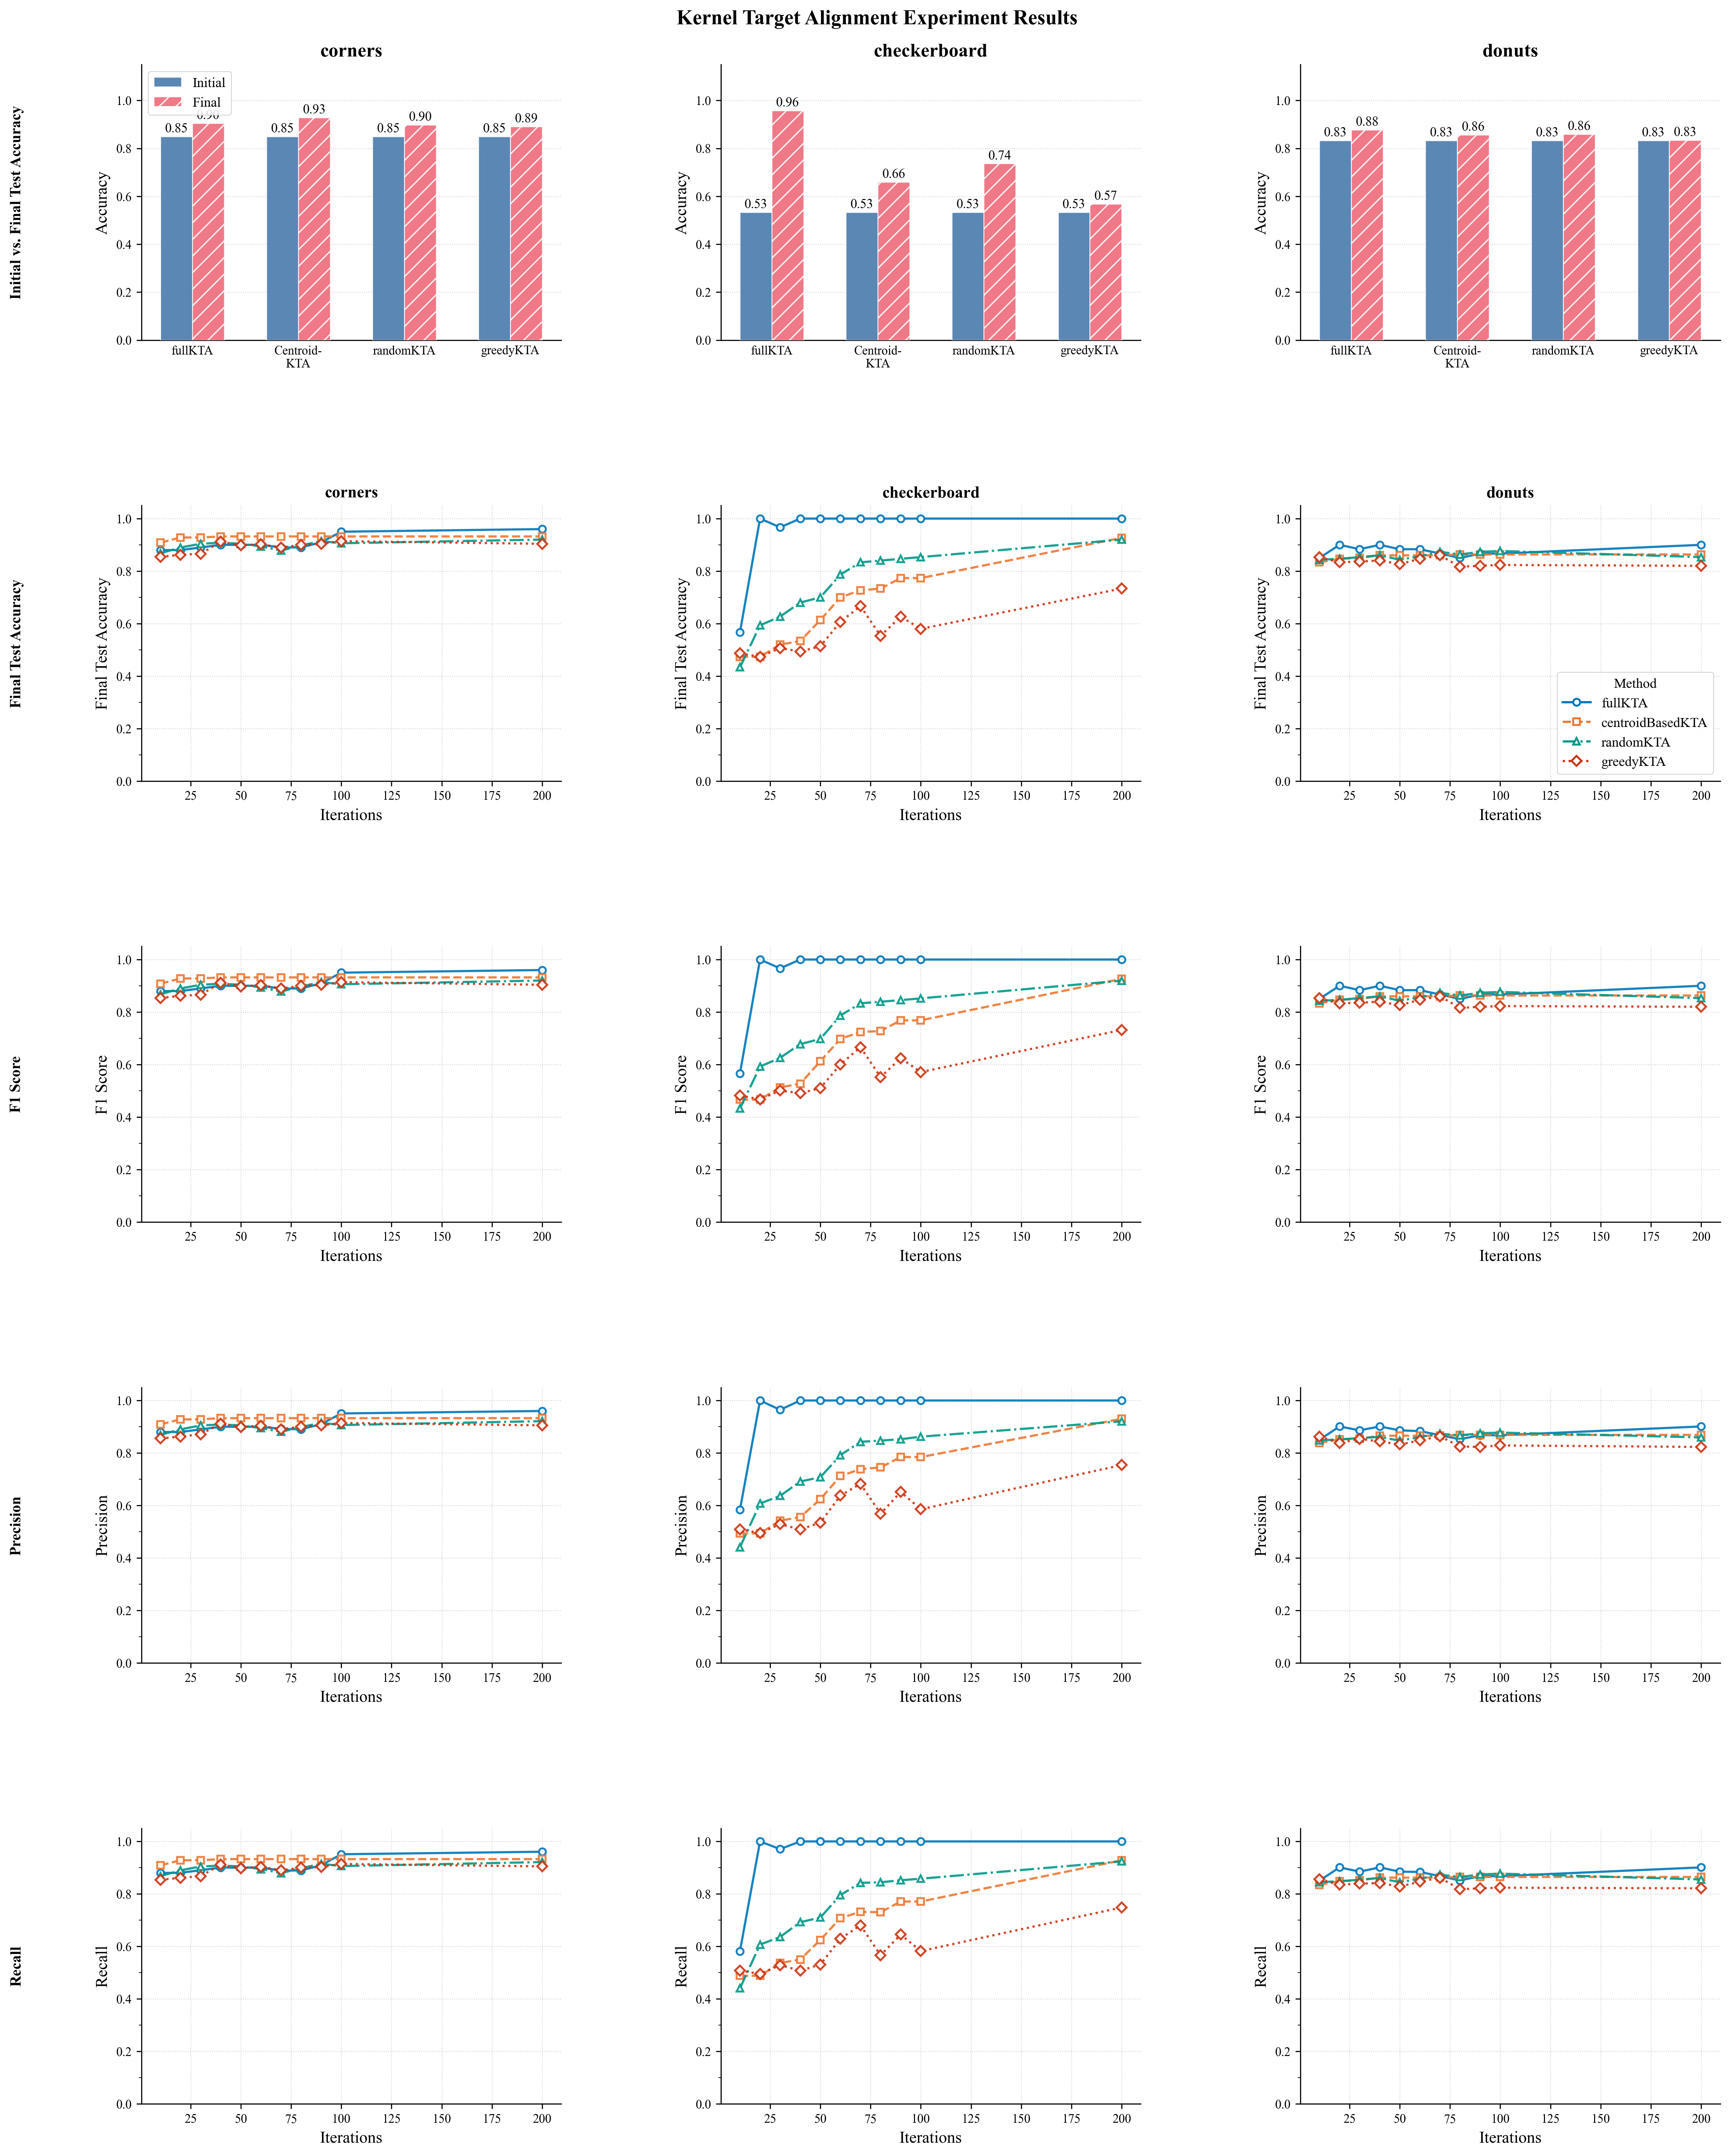

Saved: kta_results_panel.png  /  kta_results_panel.pdf


In [16]:
plot_experiment_panel(final_results, datasets, methods, centroid_values)

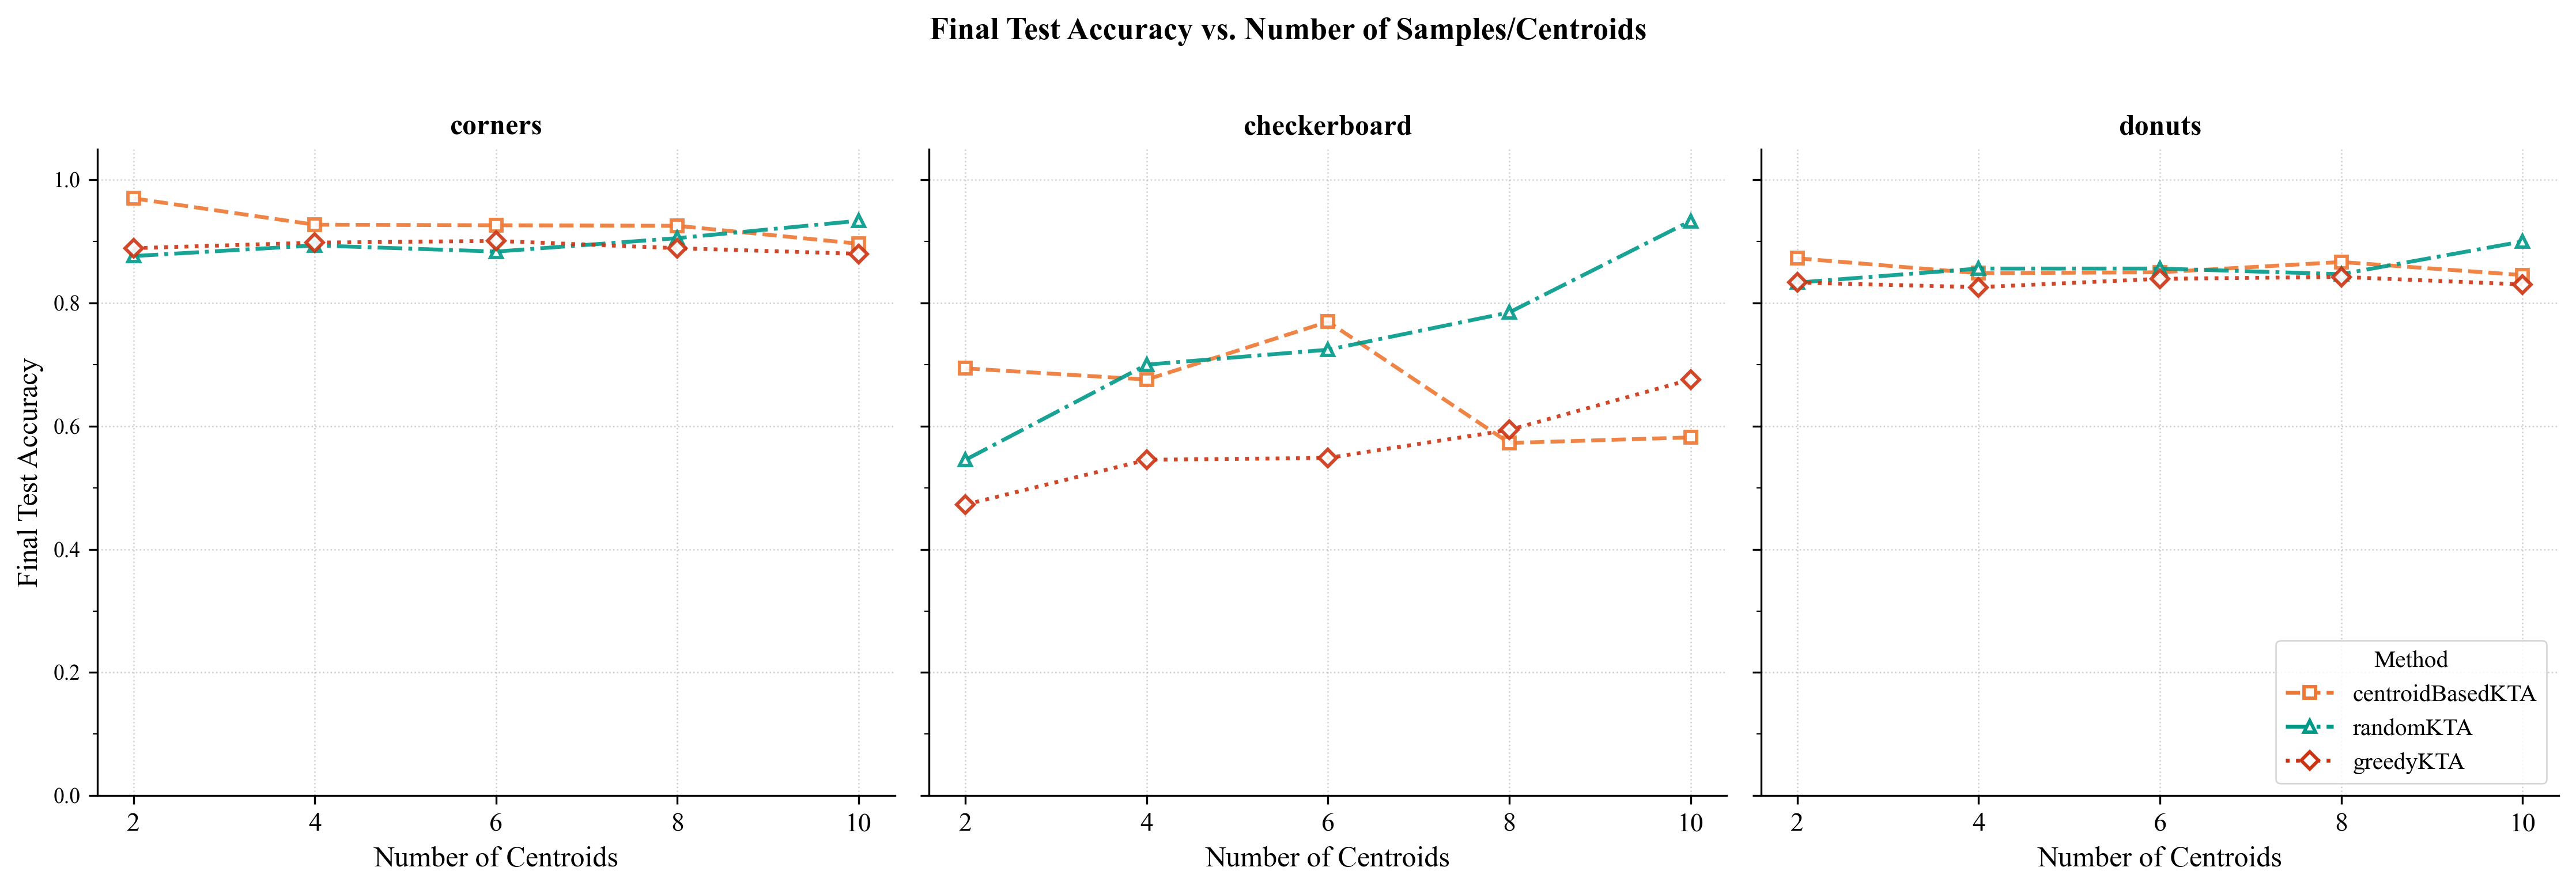

Saved: kta_centroid_sweep.png  /  kta_centroid_sweep.pdf


In [17]:
plot_centroid_sweep_panel(final_results, datasets)